##### Setup

###### Imports

In [23]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets
from torchvision.transforms import ToTensor, Lambda

import numpy as np
import matplotlib.pyplot as plt
from collections import OrderedDict

from svipy.normflow import scalarConditionedNetworkCNN, identityTimeEmbedding, timeConditionedField, continuousNormFlow
from svipy.diffusion import linearConditionalPath, conditionalFlowMatcher
from svipy.model import reshape, earlyStopping

###### Load data

In [3]:
class imageOnlyDataset(torch.utils.data.Dataset):
    '''
    Class to extract only the images as labels not needed for VAEs.
    '''
    def __init__(self, original, index):
        self.__original = original
        self.__index = index

    @property
    def original(self):
        return self.__original

    @property
    def index(self):
        return self.__index

    def __len__(self):
        return len(self.original)

    def __getitem__(self, index):
        return self.original[index][self.index]

In [4]:
# ToTensor() scales eveything to [0, 1)
thresh = Lambda(lambda x: torch.where(ToTensor()(x) > 0.5, 1.0, 0.0))

# scatter_ to get a one-hot vector
onehot = Lambda(lambda y: torch.zeros(10, dtype=torch.float).scatter_(0, torch.tensor(y), value=1))

trainData = datasets.MNIST(root="../data", train=True, download=True, transform=thresh, target_transform=onehot)
testData = datasets.MNIST(root="../data", train=False, download=True, transform=thresh, target_transform=onehot)

trainImageData = imageOnlyDataset(trainData, 0)  # remove the labels as we dont need them
testImageData = imageOnlyDataset(testData, 0)
print(len(trainData), len(testData), len(trainImageData), len(testImageData))

60000 10000 60000 10000


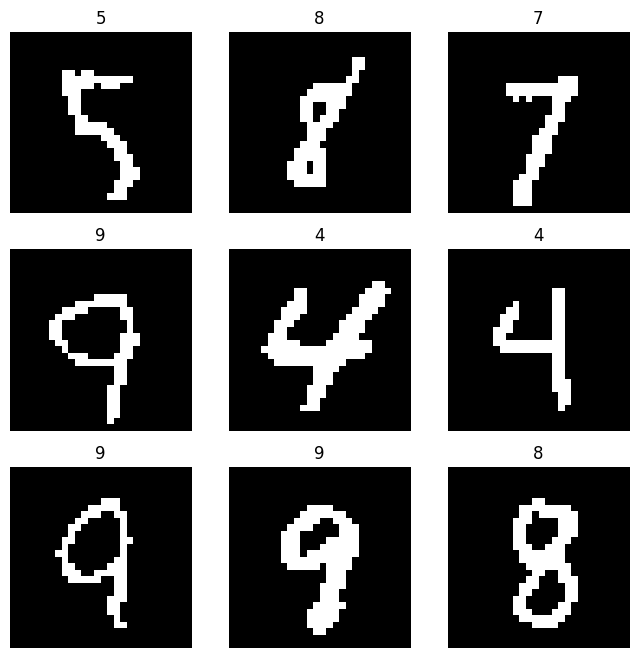

In [5]:
# show some randomly picked numbers
figure = plt.figure(figsize=(8, 8))
cols, rows = 3, 3
for i in range(1, cols * rows + 1):
    sidx = torch.randint(len(trainData), size=(1,)).item()
    img, label = trainData[sidx]
    figure.add_subplot(rows, cols, i)
    plt.title(str(torch.argmax(label, dim=0).item()))
    plt.axis("off")
    plt.imshow(img.squeeze(), cmap='gray')
plt.show()

###### Hardware Specs

In [6]:
cudaavailable = torch.cuda.is_available()
mpsavailable = torch.backends.mps.is_available()
curr_device = torch.cuda.current_device()

device = torch.device("cuda" if cudaavailable else "mps" if mpsavailable else "cpu")
device_count = torch.cuda.device_count() 
device_name =  torch.cuda.get_device_name(0)

print(f'Cuda available: {cudaavailable}')
print(f'Current device: {curr_device}')
print(f'Device: {device}')
print(f'Device count: {device_count}')
print(f'Device name: {device_name}')

Cuda available: True
Current device: 0
Device: cuda
Device count: 1
Device name: NVIDIA GeForce GTX 970


##### VAEs with norm flows

###### Conditional Flow Matching

In [20]:
tcn = scalarConditionedNetworkCNN(1, [(32, 3), (32, 3)], t_dim=1) 
embed = identityTimeEmbedding()
tcf = timeConditionedField(tcn, embed)

path = linearConditionalPath()

model_cfm = conditionalFlowMatcher(path, tcf)

In [21]:
learning_rate = 0.001
batch_size = 128
epochs = 50

trainLoader = DataLoader(trainImageData, batch_size=batch_size, shuffle=True)
validLoader = DataLoader(testImageData, batch_size=batch_size, shuffle=True)
optimizer = torch.optim.Adam(model_cfm.parameters(), lr=learning_rate)
stopper = earlyStopping(patience=10, minDelta=0.1, mode='min', restoreBestWeights=True)

In [22]:
%%time 
model_cfm.trainLoop(trainLoader, optimizer, epochs, 
                    reportIters=100, scheduler=None,
                    checkpointPath='../checkpoints/mnist_cfm/',
                    checkPointName='cfm',
                    validDataLoader=validLoader,
                    earlyStopper=stopper
                   )

Epoch 1
-------------------------------
totalLoss: 353.392822[12800/60000]
totalLoss: 269.957825[25600/60000]
totalLoss: 228.168320[38400/60000]
totalLoss: 245.665268[51200/60000]
Validation Error: 203.159499
Epoch 2
-------------------------------
totalLoss: 191.915115[12800/60000]
totalLoss: 196.117569[25600/60000]
totalLoss: 187.647293[38400/60000]
totalLoss: 173.575836[51200/60000]
Validation Error: 164.942225
Epoch 3
-------------------------------
totalLoss: 155.908646[12800/60000]
totalLoss: 150.624863[25600/60000]
totalLoss: 162.311371[38400/60000]
totalLoss: 156.813690[51200/60000]
Validation Error: 148.586629
Epoch 4
-------------------------------
totalLoss: 145.372681[12800/60000]
totalLoss: 138.761322[25600/60000]
totalLoss: 139.852066[38400/60000]
totalLoss: 136.737076[51200/60000]
Validation Error: 140.885060
Epoch 5
-------------------------------
totalLoss: 149.871185[12800/60000]
totalLoss: 133.548523[25600/60000]
totalLoss: 135.013550[38400/60000]
totalLoss: 133.6633

In [24]:
cnf = continuousNormFlow(tcf)

In [28]:
trainData[0][0].shape

torch.Size([1, 28, 28])

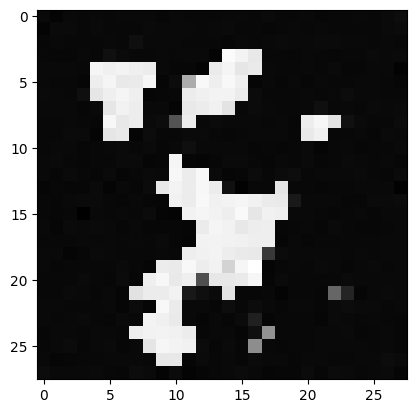

In [39]:
x0 = torch.randn([1, 1, 28, 28])

img = cnf.generate(x0)[0].cpu().detach()
img = img.numpy().squeeze()

plt.imshow(img, cmap='gray')